In [ ]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import wine_common as wine
import importlib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split()
X_tr, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
features_names = df_train.drop(columns=['quality', 'type']).columns
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,5199,1298
1,Number of features,11,11
2,Class values,"[3, 4, 5, 6, 7, 8, 9]","[3, 4, 5, 6, 7, 8]"
3,Class balance,"quality 3 = 24, quality 4 = 182, quality 5 = 1...","quality 3 = 6, quality 4 = 34, quality 5 = 421..."


In [5]:
X_tr.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.214876,0.060000,0.192771,0.027607,0.064784,0.274914,0.631922,0.128976,0.604651,0.157303,0.246377
1,0.272727,0.120000,0.204819,0.211656,0.096346,0.233677,0.596091,0.221515,0.271318,0.174157,0.159420
2,0.231405,0.220000,0.144578,0.065951,0.247508,0.316151,0.449511,0.146520,0.348837,0.151685,0.202899
3,0.165289,0.146667,0.072289,0.015337,0.044850,0.384880,0.511401,0.101793,0.511628,0.207865,0.362319
4,0.520661,0.246667,0.138554,0.019939,0.121262,0.061856,0.039088,0.204935,0.387597,0.241573,0.188406


In [6]:
X_ts.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.431034,0.193237,0.454545,0.045662,0.129902,0.020833,0.011547,0.396736,0.371901,0.270270,0.716667
1,0.215517,0.067633,0.404040,0.036530,0.068627,0.076389,0.184758,0.156937,0.256198,0.189189,0.700000
2,0.250000,0.570048,0.020202,0.050228,0.088235,0.013889,0.009238,0.563716,0.561983,0.243243,0.250000
3,0.181034,0.193237,0.494949,0.278539,0.083333,0.208333,0.496536,0.507219,0.322314,0.198198,0.216667
4,0.232759,0.125604,0.393939,0.073059,0.066176,0.104167,0.219400,0.313245,0.347107,0.297297,0.483333


<hr/>

<h4>Data Analysis</h4>

<h5>Data Distribution</h5>
<p>The analysis starts from the distribution of the target variable (wine quality), which shows a strong imbalance toward intermediate quality levels 5 and 6. This characteristic has important implications for feature relevance interpretation and model evaluation.</p>

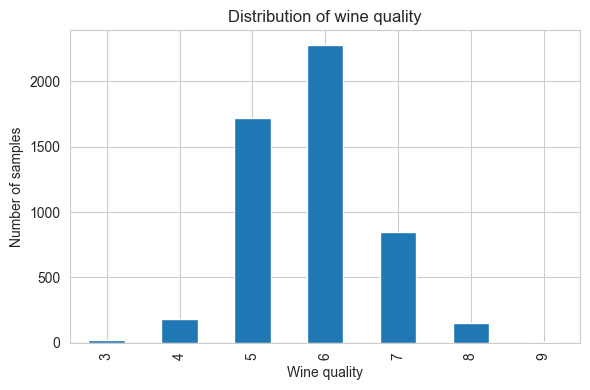

In [7]:
plt.figure(figsize=(6,4))
df_train['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wine quality')
plt.ylabel('Number of samples')
plt.title('Distribution of wine quality')
plt.tight_layout()
plt.show()

<h5>Data Comparison</h5>
<p>Compare target with feature by means of boxplot.</p>
$$p(x_j | y) $$

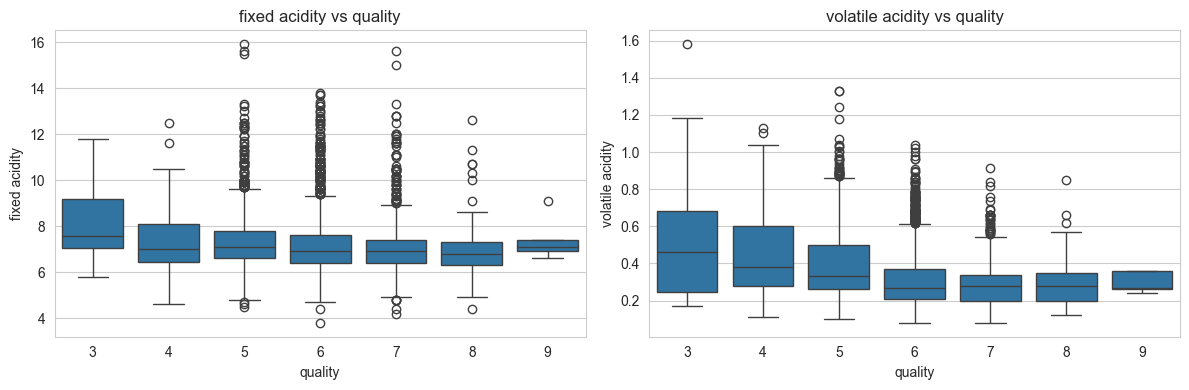

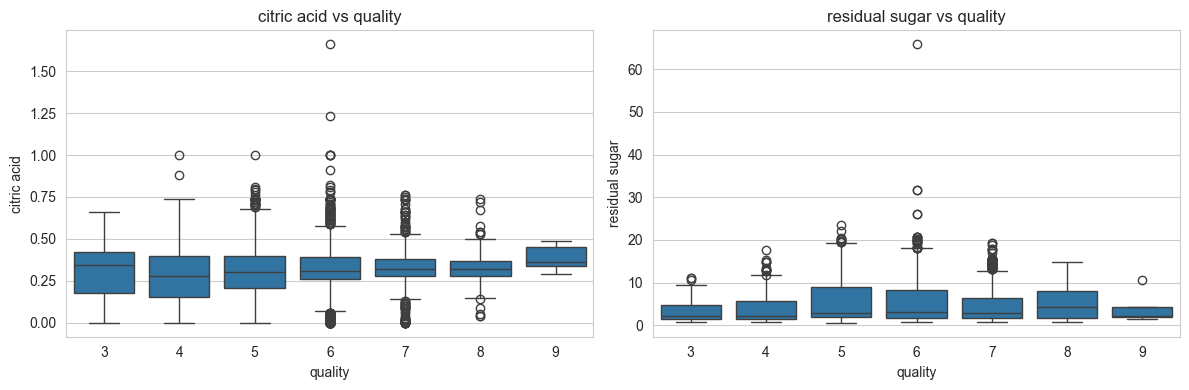

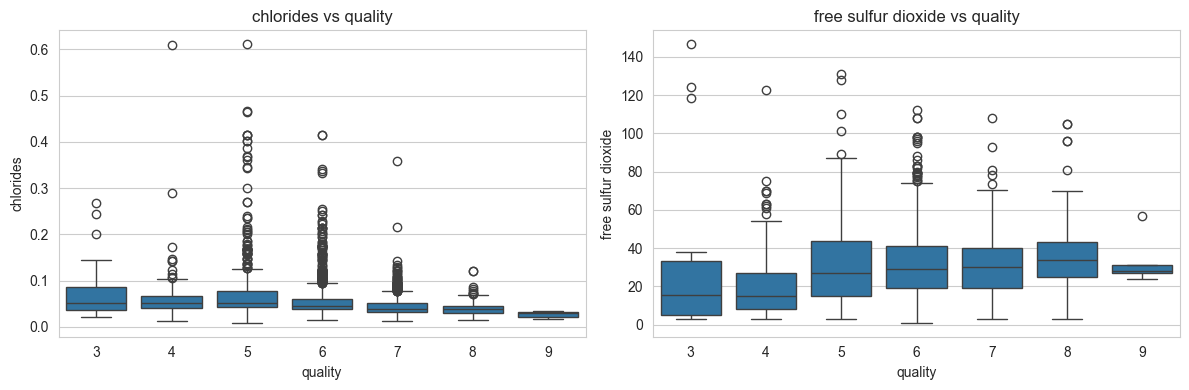

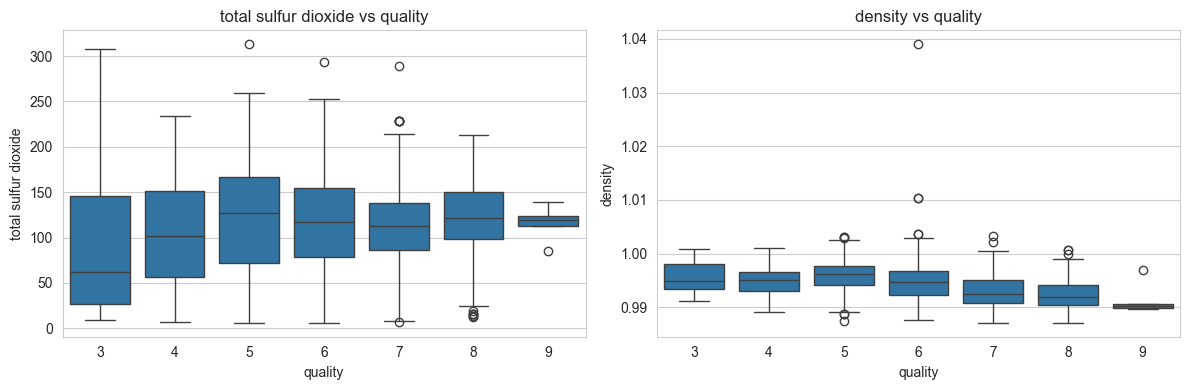

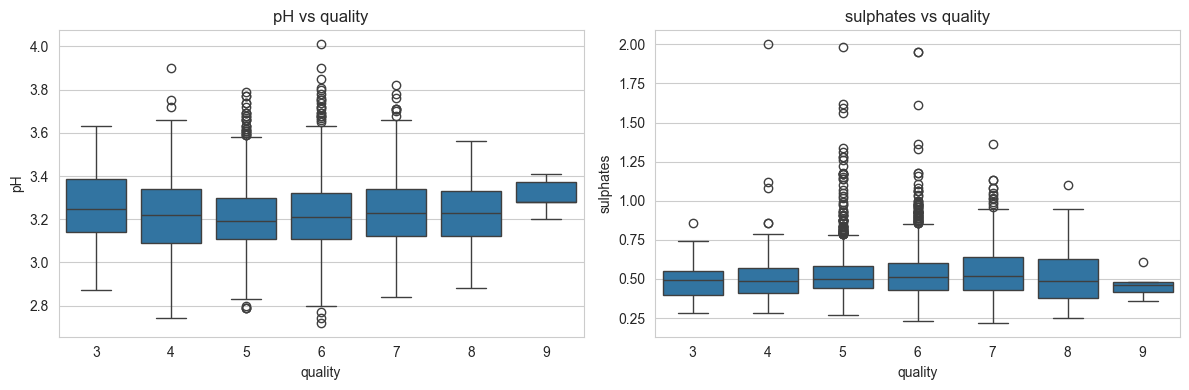

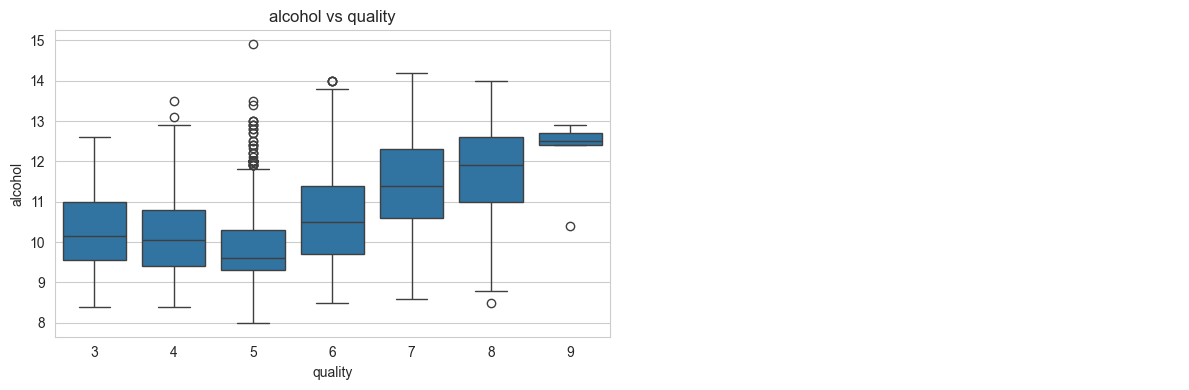

In [8]:
def boxplot_features_pairwise(df, features, target='quality'):
    # Place box feature side by side
    for i in range(0, len(features), 2):

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        # Left feature
        f1 = features[i]
        sns.boxplot(
            x=target,
            y=f1,
            data=df,
            ax=axes[0]
        )
        axes[0].set_title(f'{f1} vs {target}')

        # Right feature
        if i + 1 < len(features):
            f2 = features[i + 1]
            sns.boxplot(
                x=target,
                y=f2,
                data=df,
                ax=axes[1]
            )
            axes[1].set_title(f'{f2} vs {target}')
        else:
            # With odd nr of features we hide the second boxplot
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()


boxplot_features_pairwise(df_train, features_names)

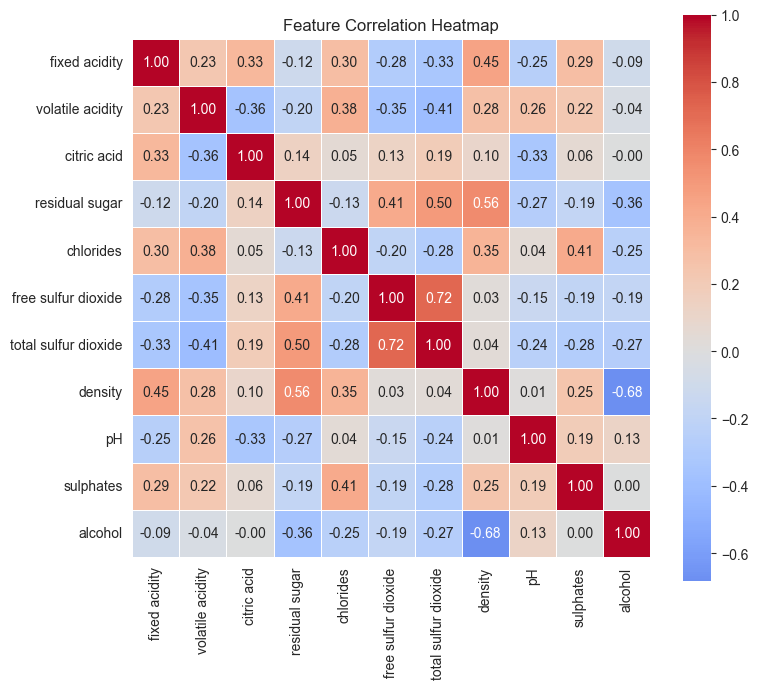

In [9]:
# matrice di correlazione
corr = df_train[features_names].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,          # <-- mostra i valori
    fmt=".2f",           # <-- 2 cifre decimali (perfetto)
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()